In [3]:
import pickle
import FF_Demo
import numpy as np

In [4]:
rnn1 = pickle.load(open("model16-2000-full-period-20-20-0.5",'rb'))

In [5]:
rnn2 = pickle.load(open("model16-2500-full-period-20-20-0.5",'rb'))


In [6]:
rnn3 = pickle.load(open("model16-2000-full-period-40-20-0.3",'rb'))

In [7]:
rnn4 = pickle.load(open("model15-1000-full-period-20-20-0.5",'rb'))

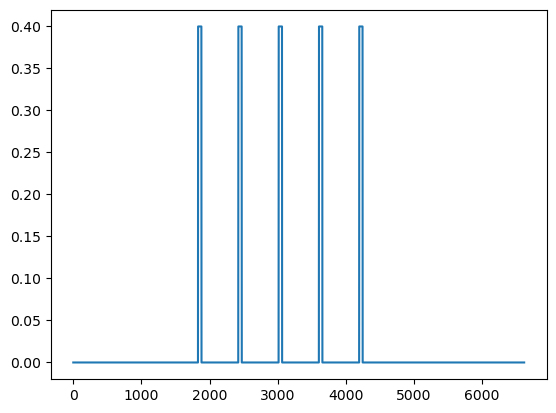

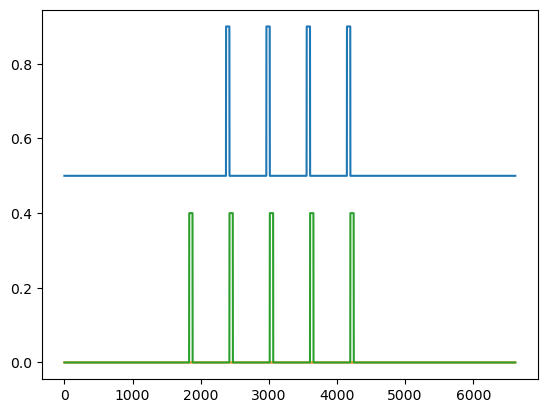

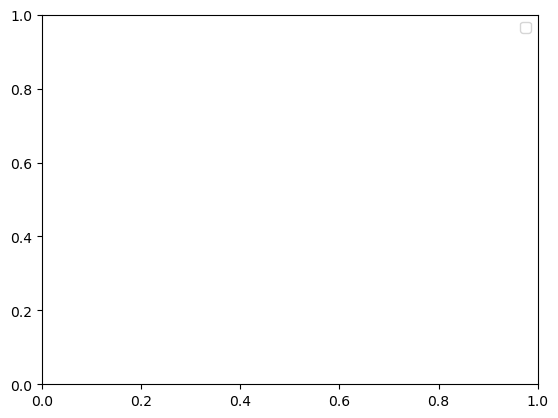

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import time

def random_pulses(dt, showplots = 0):
    n_events = 5
    hint = 'nohint'
    #period = 0.5+.15*2*(np.random.uniform()-.5);
    period = np.random.uniform()
    ITIb = 0.7 #min. ITI time
    ITIl = 2.0 #mean ITI time
    ITI = ITIb + np.random.exponential(ITIl) #compute ITI for that trial
    fin, fout, fhint = trial_pulse_prediction(dt, period, n_events, ITI, hint)
    if showplots == 1:
        plt.figure()
        plt.plot(fout)
        plt.plot(fhint)
        plt.plot(fin)
        plt.show()
        plt.legend(['Target','Hints','Input'])
    return fin, fout, fhint

def trial_pulse_prediction(dt, period, n_events, ITI, hint):
    output_offset = -0.5
    pulse_width = 0.05 # 0.05
    pulse_height = 0.02 / pulse_width
    output_timeshift = -pulse_width
    pulse_samples = np.round(pulse_width/dt).astype('int')
    
    n_timepoints = np.round((period*n_events+ITI)/dt).astype('int')
    
    
    timepoints = np.arange(0, n_timepoints)*dt

    
    fin = np.zeros((n_timepoints,1))
    fout = np.zeros((n_timepoints,1))
    
    fin[ np.mod(timepoints- ITI/2, period) < pulse_width ,0] = pulse_height
    
    fin[ timepoints < ITI/2 ,0] = 0
    fin[ timepoints > ITI/2 + period*n_events,0] = 0
    
    a = np.where(fin != 0)
    
    a = np.array_split(a[0],5)
    
    
    #concatenate with time delay
    idx = a[4][0]
    #fin = np.concatenate((fin[:idx], np.zeros((200, 1)), fin[idx:]), axis=0)
    #fin = fin[:-200]
    plt.plot(fin)
    
    fout = fin - output_offset
    
    fout[timepoints < ITI/2+pulse_width,0] = -output_offset
    fout[0:-1-pulse_samples]=fout[pulse_samples:-1]
    
    # desired output signals and hint signals
    fhint = np.zeros(fin.shape)
    
    
    
    return fin, fout, fhint

random_pulses(dt=0.001,showplots=1)


def specific_pulse(dt, showplots = 0, period = 0.4):
    n_events = 5
    hint = 'nohint'
    #period = 0.7 
    ITIb = 0.7 #min. ITI time
    ITIl = 2.0 #mean ITI time
    #print(period)
    ITI = ITIb + np.random.exponential(ITIl) #compute ITI for that trial
    fin, fout, fhint = trial_pulse_prediction(dt, period, n_events, ITI, hint)
    if showplots == 1:
        plt.figure()
        plt.plot(fout)
        plt.plot(fhint)
        plt.plot(fin)
        plt.show()
        plt.legend(['Target','Hints','Input'])
    return fin, fout, fhint


0
1
Initializing.....
Testing: 10 trials
..........
The predicted pulse peak is 0.022 seconds late
The width of the predicted pulse at half-max is 125.0% the size of input
1
Initializing.....
Testing: 10 trials
..........
The predicted pulse peak is 0.031 seconds late
The width of the predicted pulse at half-max is 215.0% the size of input
1
Initializing.....
Testing: 10 trials
..........
The predicted pulse peak is 0.111 seconds early
The width of the predicted pulse at half-max is 277.5% the size of input
1
Initializing.....
Testing: 10 trials
..........
The predicted pulse peak is 0.0 seconds late
The width of the predicted pulse at half-max is 130.0% the size of input
1
Initializing.....
Testing: 10 trials
..........
The predicted pulse peak is 0.028 seconds late
The width of the predicted pulse at half-max is 157.5% the size of input
1
Initializing.....
Testing: 10 trials
..........
The predicted pulse peak is 0.006 seconds early
The width of the predicted pulse at half-max is 177

C:\Users\Manav\AppData\Local\Temp\ipykernel_20988\2795333706.py:17: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure()


....
Testing: 10 trials
..........
The predicted pulse peak is 0.027 seconds late
The width of the predicted pulse at half-max is 180.0% the size of input
1
Initializing.....
Testing: 10 trials
..........
The predicted pulse peak is 0.079 seconds late
The width of the predicted pulse at half-max is 282.5% the size of input
1
Initializing.....
Testing: 10 trials
..........
The predicted pulse peak is 0.05 seconds late
The width of the predicted pulse at half-max is 162.5% the size of input
1
Initializing.....
Testing: 10 trials
..........
The predicted pulse peak is 0.03 seconds late
The width of the predicted pulse at half-max is 130.0% the size of input
1
Initializing.....
Testing: 10 trials
..........
The predicted pulse peak is 0.05 seconds late
The width of the predicted pulse at half-max is 172.5% the size of input
1
Initializing.....
Testing: 10 trials
..........
The predicted pulse peak is 0.014 seconds early
The width of the predicted pulse at half-max is 167.5% the size of inp

Initializing.....
Testing: 10 trials
..........
The predicted pulse peak is 0.12 seconds early
The width of the predicted pulse at half-max is 497.5% the size of input


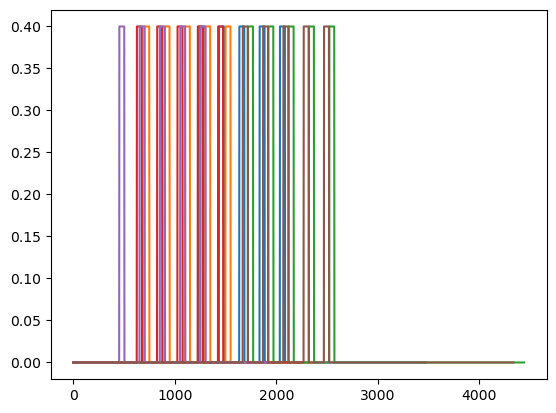

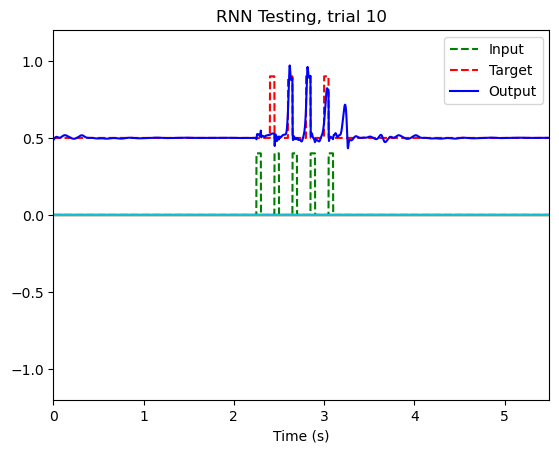

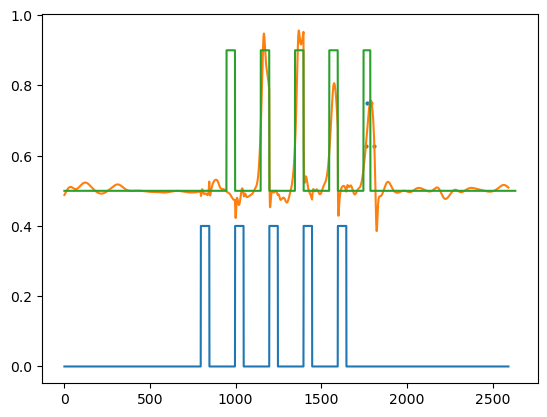

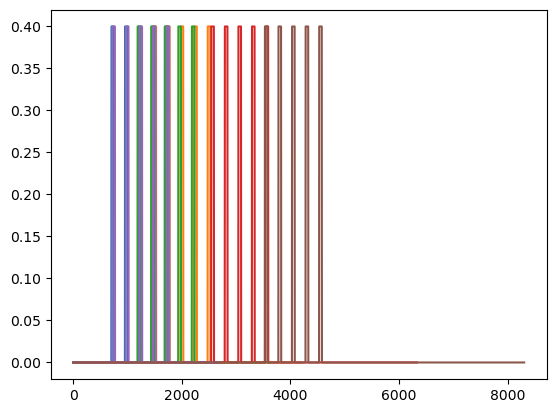

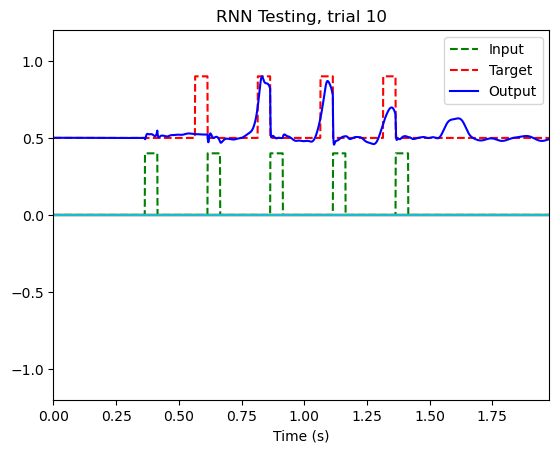

...

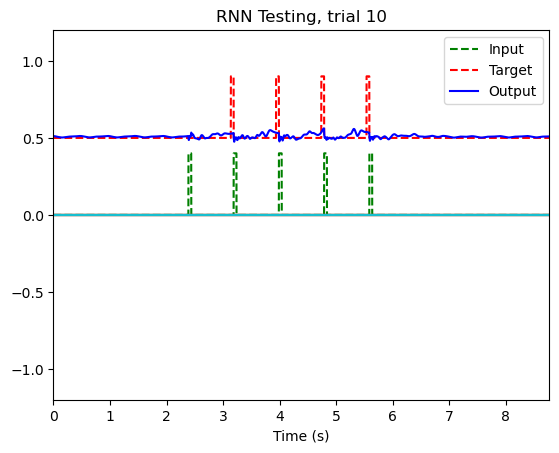

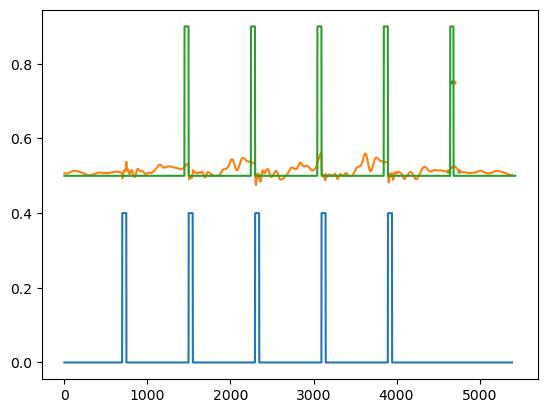

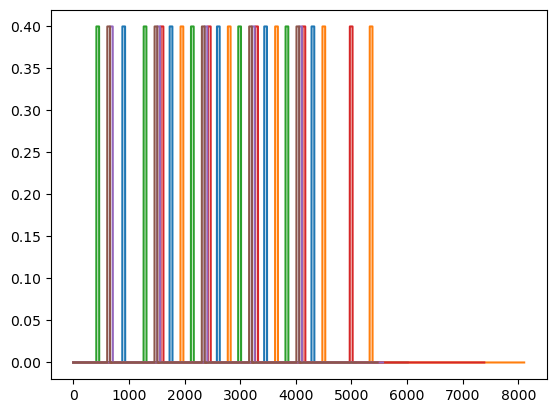

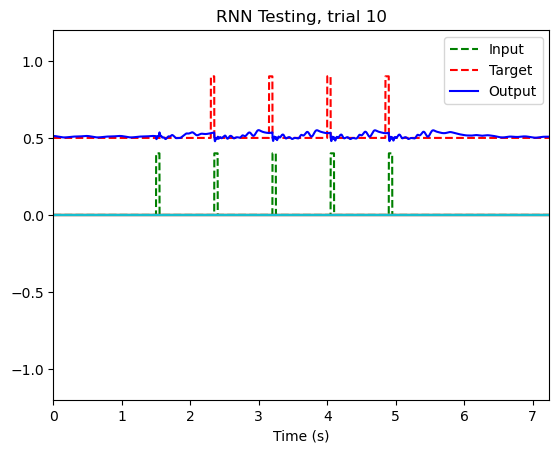

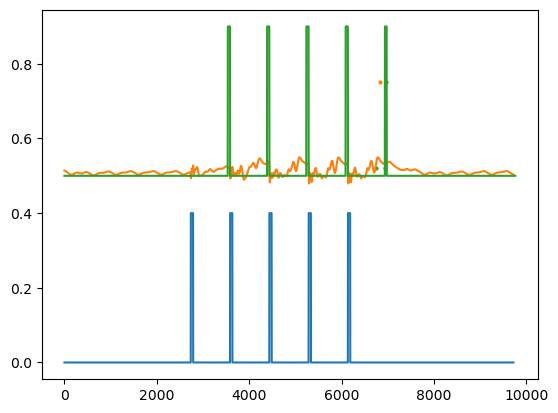

<Figure size 640x480 with 0 Axes>

In [9]:
all_width = []
all_position = []
for rnn in [rnn1,rnn2,rnn3,rnn4]:
    print(0)
    #defines arrays to store errors for each period
    half_max_width = [] 
    position_error = []

    #defines range for testing periods
    range_array = np.arange(0.2,0.9,0.05)

    #loop to test multiple periods
    for item in range_array:
        print(1)
        #calls test function from FF_demo.py on different periods
        x = rnn.test(specific_pulse, period = item)
        plt.figure()

        #stores the target output and model output
        fin = x[0][0];ftarg = x[0][1]; fout = x[0][2]

        #finds each pulse in the target output and stores the indicies in groups of 5
        a = np.where(ftarg == np.max(ftarg))
        a = np.array_split(a[0],5)

        #finds the location of the predicted pulse and inserts it
        idx = a[4][0] + abs(a[4][0] -  a[3][0])
        ftarg = np.concatenate((ftarg[:idx], np.full_like(np.zeros((40, 1)),0.9), ftarg[idx:]), axis=0)

        #plots the output with the predicted pulse
        plt.plot(fin)
        plt.plot(fout)
        plt.plot(ftarg)

        #defines positions: check range = how far left and right values are checked
        check_range = 100 
        check_left = idx - check_range
        check_right = idx + check_range
        check_slice = fout[check_left:check_right]

        #find the maximal value of model output
        max_val = np.max(check_slice)

        #finds index of maximal value of model output relative to slice
        max_out_near_predict = np.argmax(check_slice)

        #absolute index in fout of maxical value
        model_max_index = max_out_near_predict + check_left

        #target index of predict pulse
        predict = idx + 20

        #plots target prediction point and model prediction point
        plt.scatter(predict, 0.75,4)
        plt.scatter(model_max_index,0.75,4)

        #calculates the time error in seconds
        time_from_target = 0.001*((check_left+max_out_near_predict)-(predict))

        #reports time error
        if time_from_target < 0: 
            print(f"The predicted pulse peak is {abs(time_from_target)} seconds early")
        else:
            print(f"The predicted pulse peak is {time_from_target} seconds late")

        #stores time error
        position_error.append(time_from_target)

        #check index centred on model predict
        check_model_left = model_max_index - check_range

        half_max = 0.25+max_val/2

        #calculates the index for 1/2 max out put for left side and right side of the pulse
        pulse_left = check_model_left + np.abs(fout[check_model_left:model_max_index] - half_max).argmin()
        pulse_right = model_max_index + np.abs(fout[model_max_index:model_max_index+100] - half_max).argmin()

        #plots the 1/2 max on the left and right size
        plt.scatter([pulse_left,pulse_right], [half_max,half_max],4)
        #plt.scatter(pulse_right, 0.25+max_val/2,4)

        #calculates size of model predict relative to target predict
        pulse_size_error =  100*abs(pulse_left-pulse_right)/40

        print(f"The width of the predicted pulse at half-max is {pulse_size_error}% the size of input")

        #stores size of model predict
        half_max_width.append(pulse_size_error)
        plt.figure()
        
    all_width.append(half_max_width)
    all_position.append(position_error)

#print(error_to_plot)

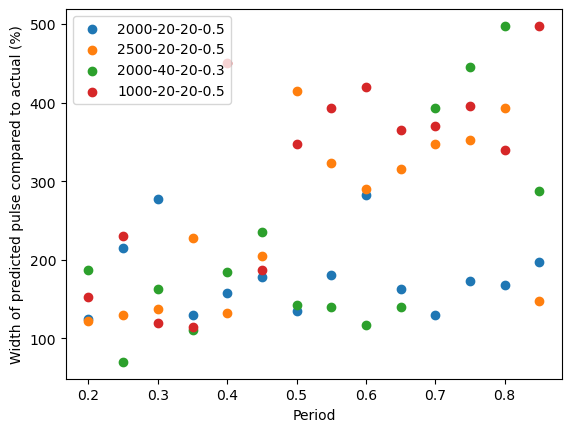

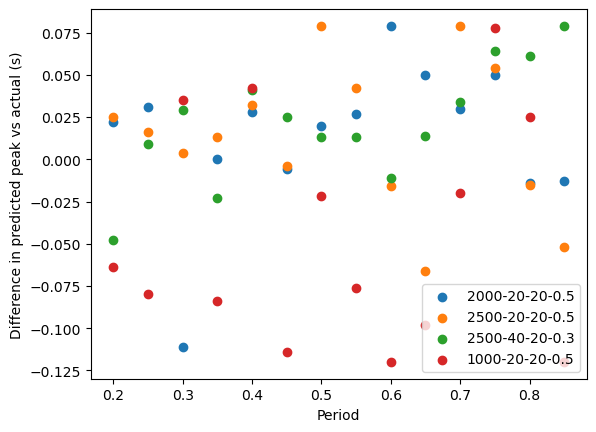

In [11]:
#from sklearn.metrics import r2_score

#print(all_width)
#print(all_position)
#a,b = np.polyfit(range_array, all_width, 1)

plt.figure()
for i in range(len(all_width)):
    plt.scatter(range_array,all_width[i])
plt.legend(["2000-20-20-0.5","2500-20-20-0.5","2000-40-20-0.3","1000-20-20-0.5"])
#plt.scatter(range_array, all_width)
#plt.plot(range_array, a*range_array+b)
plt.ylabel("Width of predicted pulse compared to actual (%)")
plt.xlabel("Period")
plt.savefig('pulse_width_scatter.png', transparent=True)

#a,b = np.polyfit(range_array, all_position, 1)

plt.figure()
for i in range(len(all_position)):
    plt.scatter(range_array,all_position[i])
plt.legend(["2000-20-20-0.5","2500-20-20-0.5","2500-40-20-0.3","1000-20-20-0.5"])
plt.ylabel("Difference in predicted peak vs actual (s)")
plt.xlabel("Period")
plt.savefig('pulse_timing_scatter.png', transparent=True)
#plt.scatter(range_array, all_position)
#plt.plot(range_array, a*range_array+b)
plt.show()


In [12]:
np.save("Model_comaprison_arrays", (all_width, all_position))

0
1
Initializing.....
Testing: 10 trials
..........
The predicted pulse peak is 0.012 seconds late
The width of the predicted pulse at half-max is 110.0% the size of input
1
Initializing.....
Testing: 10 trials
..........
The predicted pulse peak is 0.032 seconds late
The width of the predicted pulse at half-max is 212.5% the size of input
1
Initializing.....
Testing: 10 trials
..........
The predicted pulse peak is 0.111 seconds early
The width of the predicted pulse at half-max is 280.0% the size of input
1
Initializing.....
Testing: 10 trials
..........
The predicted pulse peak is 0.0 seconds late
The width of the predicted pulse at half-max is 130.0% the size of input
1
Initializing.....
Testing: 10 trials
..........
The predicted pulse peak is 0.028 seconds late
The width of the predicted pulse at half-max is 157.5% the size of input
1
Initializing.....
Testing: 10 trials
..........
The predicted pulse peak is 0.005 seconds early
The width of the predicted pulse at half-max is 177

C:\Users\Manav\AppData\Local\Temp\ipykernel_20988\371081525.py:23: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure()


....
Testing: 10 trials
..........
The predicted pulse peak is 0.027 seconds late
The width of the predicted pulse at half-max is 180.0% the size of input
1
Initializing.....
Testing: 10 trials
..........
The predicted pulse peak is 0.079 seconds late
The width of the predicted pulse at half-max is 282.5% the size of input
1
Initializing.....
Testing: 10 trials
..........
The predicted pulse peak is 0.051000000000000004 seconds late
The width of the predicted pulse at half-max is 155.0% the size of input
1
Initializing.....
Testing: 10 trials
..........
The predicted pulse peak is 0.029 seconds late
The width of the predicted pulse at half-max is 127.5% the size of input
1
Initializing.....
Testing: 10 trials
..........
The predicted pulse peak is 0.05 seconds late
The width of the predicted pulse at half-max is 172.5% the size of input
1
Initializing.....
Testing: 10 trials
..........
The predicted pulse peak is 0.014 seconds early
The width of the predicted pulse at half-max is 167.5

Initializing.....
Testing: 10 trials
..........
The predicted pulse peak is 0.048 seconds early
The width of the predicted pulse at half-max is 432.5% the size of input


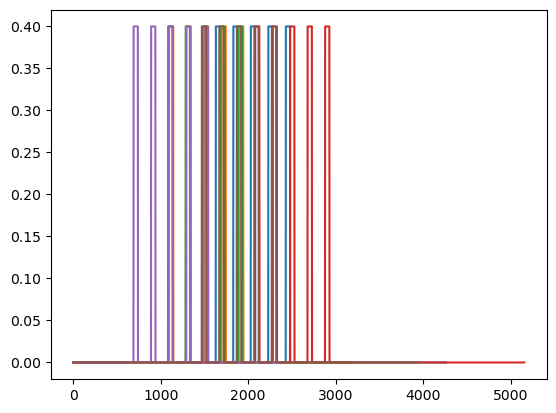

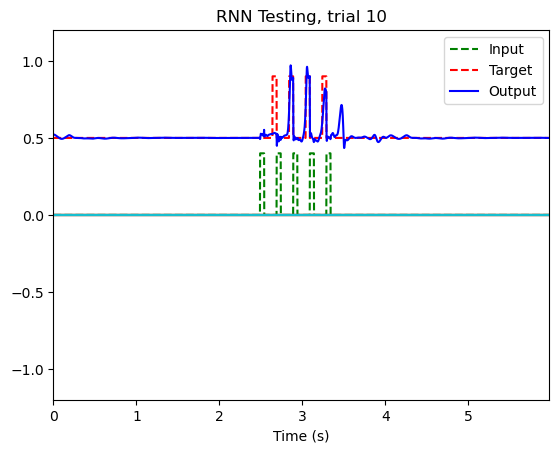

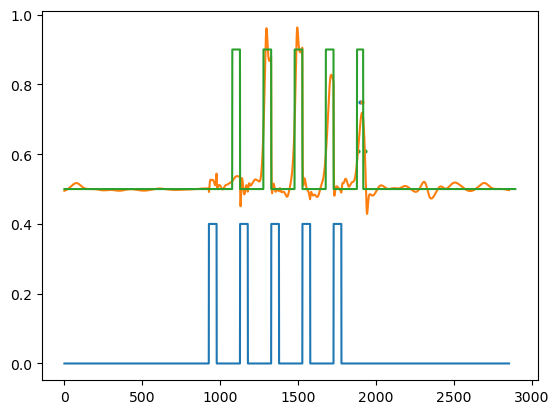

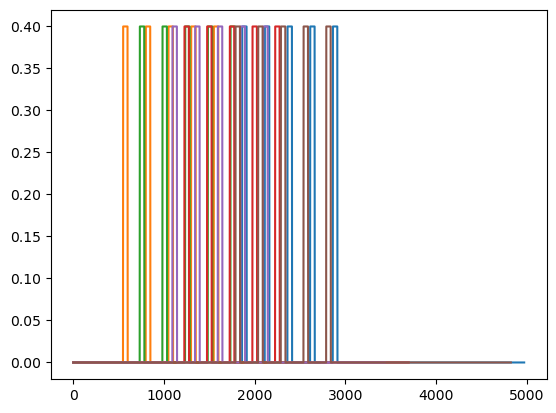

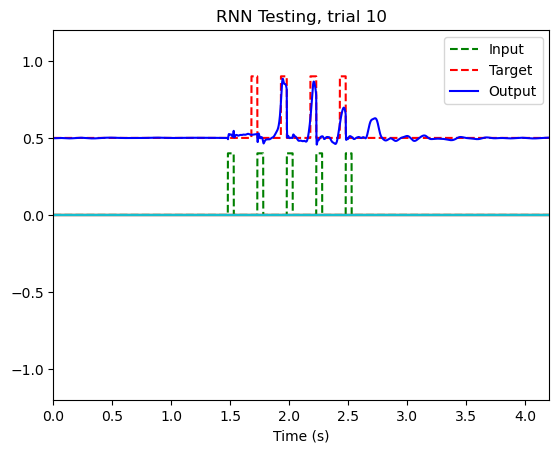

...

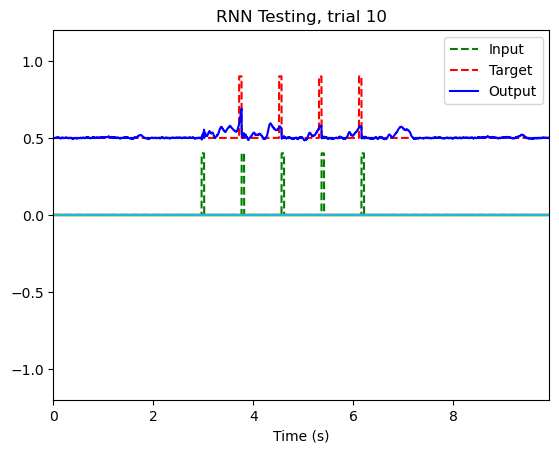

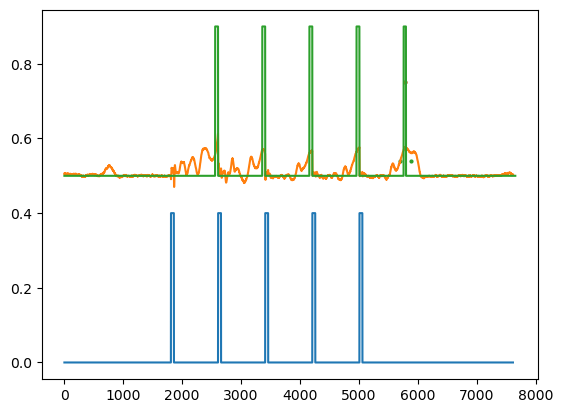

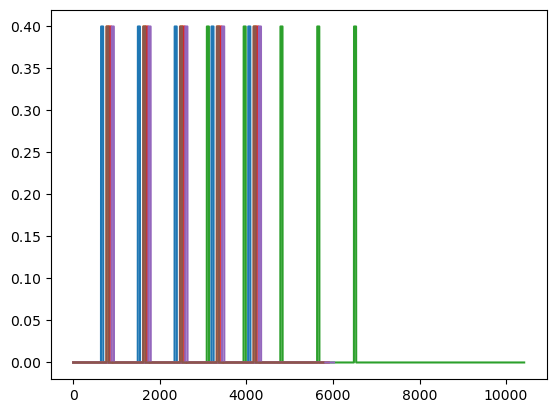

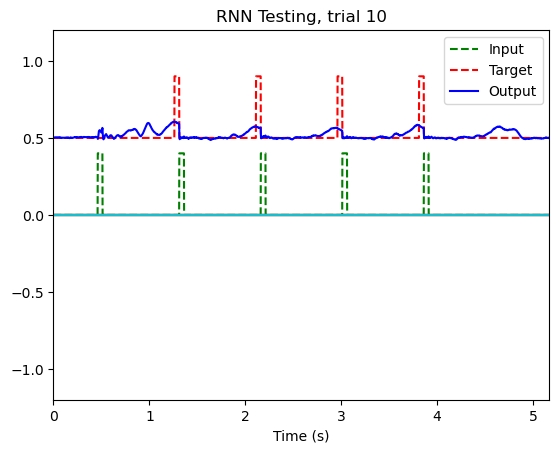

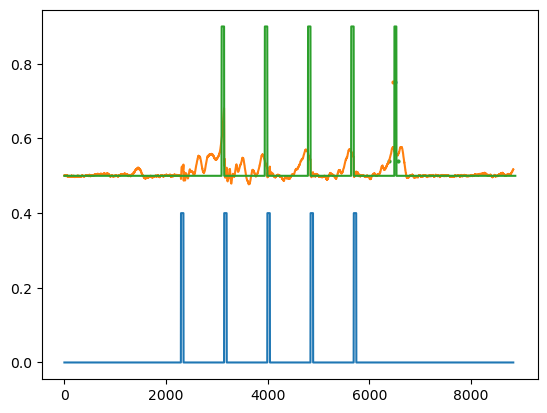

<Figure size 640x480 with 0 Axes>

In [13]:
rnn5 = pickle.load(open("model16-2000-full-period-20-20-0.5",'rb'))
rnn6 = pickle.load(open("model22-noise_std-0.1-2000-full-period-20-20-0.5",'rb'))
rnn7 = pickle.load(open("model22-noise_std-0.01-2000-full-period-20-20-0.5",'rb'))
rnn8 = pickle.load(open("model22-noise_std-0.001-2000-full-period-20-20-0.5",'rb'))


all_width = []
all_position = []
for rnn in [rnn5,rnn6,rnn7,rnn8]:
    print(0)
    #defines arrays to store errors for each period
    half_max_width = [] 
    position_error = []

    #defines range for testing periods
    range_array = np.arange(0.2,0.9,0.05)

    #loop to test multiple periods
    for item in range_array:
        print(1)
        #calls test function from FF_demo.py on different periods
        x = rnn.test(specific_pulse, period = item)
        plt.figure()

        #stores the target output and model output
        fin = x[0][0];ftarg = x[0][1]; fout = x[0][2]

        #finds each pulse in the target output and stores the indicies in groups of 5
        a = np.where(ftarg == np.max(ftarg))
        a = np.array_split(a[0],5)

        #finds the location of the predicted pulse and inserts it
        idx = a[4][0] + abs(a[4][0] -  a[3][0])
        ftarg = np.concatenate((ftarg[:idx], np.full_like(np.zeros((40, 1)),0.9), ftarg[idx:]), axis=0)

        #plots the output with the predicted pulse
        plt.plot(fin)
        plt.plot(fout)
        plt.plot(ftarg)

        #defines positions: check range = how far left and right values are checked
        check_range = 100 
        check_left = idx - check_range
        check_right = idx + check_range
        check_slice = fout[check_left:check_right]

        #find the maximal value of model output
        max_val = np.max(check_slice)

        #finds index of maximal value of model output relative to slice
        max_out_near_predict = np.argmax(check_slice)

        #absolute index in fout of maxical value
        model_max_index = max_out_near_predict + check_left

        #target index of predict pulse
        predict = idx + 20

        #plots target prediction point and model prediction point
        plt.scatter(predict, 0.75,4)
        plt.scatter(model_max_index,0.75,4)

        #calculates the time error in seconds
        time_from_target = 0.001*((check_left+max_out_near_predict)-(predict))

        #reports time error
        if time_from_target < 0: 
            print(f"The predicted pulse peak is {abs(time_from_target)} seconds early")
        else:
            print(f"The predicted pulse peak is {time_from_target} seconds late")

        #stores time error
        position_error.append(time_from_target)

        #check index centred on model predict
        check_model_left = model_max_index - check_range

        half_max = 0.25+max_val/2

        #calculates the index for 1/2 max out put for left side and right side of the pulse
        pulse_left = check_model_left + np.abs(fout[check_model_left:model_max_index] - half_max).argmin()
        pulse_right = model_max_index + np.abs(fout[model_max_index:model_max_index+100] - half_max).argmin()

        #plots the 1/2 max on the left and right size
        plt.scatter([pulse_left,pulse_right], [half_max,half_max],4)
        #plt.scatter(pulse_right, 0.25+max_val/2,4)

        #calculates size of model predict relative to target predict
        pulse_size_error =  100*abs(pulse_left-pulse_right)/40

        print(f"The width of the predicted pulse at half-max is {pulse_size_error}% the size of input")

        #stores size of model predict
        half_max_width.append(pulse_size_error)
        plt.figure()
        
    all_width.append(half_max_width)
    all_position.append(position_error)

#print(error_to_plot)

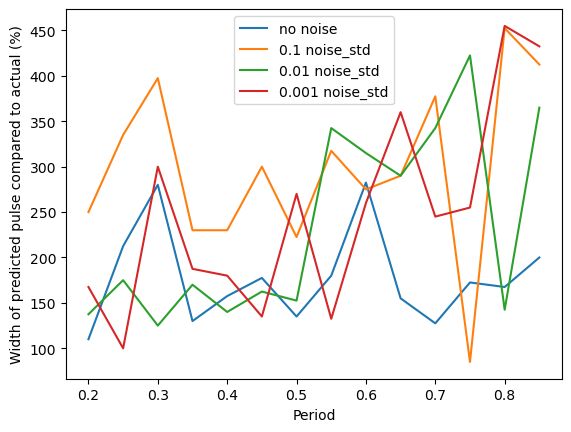

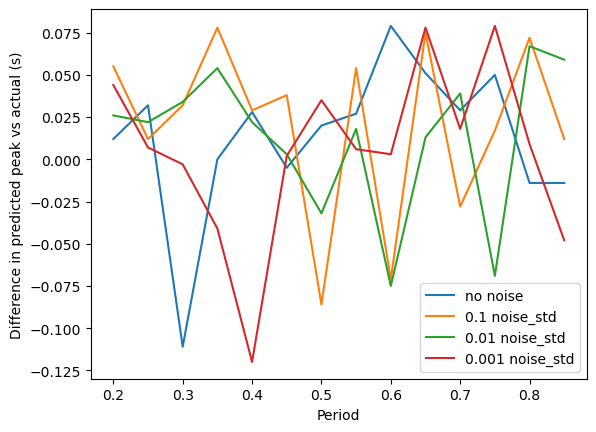

In [15]:
#from sklearn.metrics import r2_score

#print(all_width)
#print(all_position)
#a,b = np.polyfit(range_array, all_width, 1)

plt.figure()
for i in range(len(all_width)):
    plt.plot(range_array,all_width[i])
plt.legend(["no noise","0.1 noise_std","0.01 noise_std","0.001 noise_std"])
#plt.scatter(range_array, all_width)
#plt.plot(range_array, a*range_array+b)
plt.ylabel("Width of predicted pulse compared to actual (%)")
plt.xlabel("Period")
plt.savefig('pulse_width_noise_comparison.png', transparent=True)

#a,b = np.polyfit(range_array, all_position, 1)

plt.figure()
for i in range(len(all_position)):
    plt.plot(range_array,all_position[i])
plt.legend(["no noise","0.1 noise_std","0.01 noise_std","0.001 noise_std"])
plt.ylabel("Difference in predicted peak vs actual (s)")
plt.xlabel("Period")
plt.savefig('pulse_timing_noise_comparison.png', transparent=True)
#plt.scatter(range_array, all_position)
#plt.plot(range_array, a*range_array+b)
plt.show()
